## A/B тестирование

### Оглавление
1. Формулировка гипотезы
2. Сплитование данных
3. A/A-тест:
   - визуал
   - T-test
   - Манна-Уитни
4. A/B-тесты:
   - T-test
   - Манна-Уитни
   - Т-test + Манна-Уитни + сглаживание
   - Пуассоновский бутстреп
   - T-test + Манна-Уитни + бакеты
5. Общий вывод

In [1]:
import clickhouse_connect

import seaborn as sns
import matplotlib.pyplot as plt

import swifter #ускорить apply
import hashlib #хеширование
import warnings #уберем предупреждения
warnings.filterwarnings('ignore')
from scipy import stats

import pandas as pd
import numpy as np

<a id='section1'></a>
### 1. Гипотеза

Команда ML ввела новый алгоритм рекомендаций в ленте новостей.\
И сказала: "Алгоритмы предлагают пользователям более интересные посты".

Алгоритм таков: **показываем пользователю посты, похожие на те, которые он лайкал.**

Выберем метрику оценки.\
Есть явное действие, показывающее заитересованность - лайк.\
Поэтому выберем CTR из просмотров в лайки.\
Кроме того, он нормирован, что дополнительный плюс.

AA-тест проводился с 2024-09-20 по 2024-09-26 включительно.\
AB-тест проводились с с 2024-09-27 по 2024-10-03 включительно.

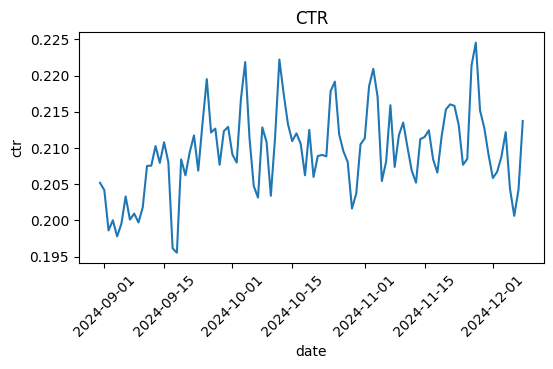

In [2]:
client = clickhouse_connect.get_client(host='localhost', port=18123, username='default', password='123')

q = """
SELECT
    time::date as date,
    sum(action = 'like')/sum(action = 'view') as ctr
FROM portfolio.feed_actions_group
GROUP BY date
"""
ctr = client.query_df(q)

plt.figure(figsize = (6,3))
ctr_g = sns.lineplot(data = ctr, x = 'date', y = 'ctr')
plt.xticks(rotation=45)
title = plt.title('CTR')

<a id='section2'></a>
### 2. Сплитование данных

Разделим пользователей на 5 групп (планируется проводить еще тесты). \
Разбиение случайное и детерменированное (учитывающее перекрытия).\
Группа в течение эксперимента не меняется.\
Поэтому применим хеширование с солью.\
Далее проверим группы на статистическую эквивалентность: одинаковое ли число пользователей, сопоставимый ли CTR.

In [3]:
#хешируем в DBeaver (ClickHouse)
# CREATE TABLE portfolio.feed_actions_group engine=MergeTree ORDEDR BY user_id settings index_granularity = 1 as 
# SELECT *, xxHash64(toString(user_id)||'exp_salt')%5 as group 
# FROM portfolio.feed_actions

In [4]:
q = """
SELECT
    group,
    count(distinct user_id) as users,
    round(sum(action = 'like')/sum(action = 'view'),4) as ctr
FROM portfolio.feed_actions_group
GROUP BY group
"""
users_group = client.query_df(q)
users_group

,group,users,ctr
0,0,31966,0.2110
1,4,31712,0.2104
2,3,32062,0.2111
3,2,31847,0.2102
4,1,31928,0.2103


В группах примерно одинаковое число пользователей и сопоставимый CTR. Все ок.

АА-тест будем проводить на 1 и 2 группах

AB-тест:
- все по-старому: 1 группа (группа A)
- предлагаются посты, похожие на лайкнутые: 2 группа (группа B)

<a id='section3'></a>
### 3. АА-тест

Проверим распределение CTR + сколько пользователей в группах (1 и 2)  2024-09-20 по 2024-09-26 включительно.\
Убедимся, что система сплитования работает хорошо.

In [5]:
q = """
SELECT group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM portfolio.feed_actions_group
WHERE toDate(time) between '2024-09-20' and '2024-09-26'
    and group in (1,2)
GROUP BY group, user_id
"""

aa = client.query_df(q)

In [6]:
#убедимся, что количество пользователей в каждой группе в указанный период равное
aa.groupby('group', as_index=False).count()

,group,user_id,likes,views,ctr
0,1,8491,8491,8491,8491
1,2,8362,8362,8362,8362


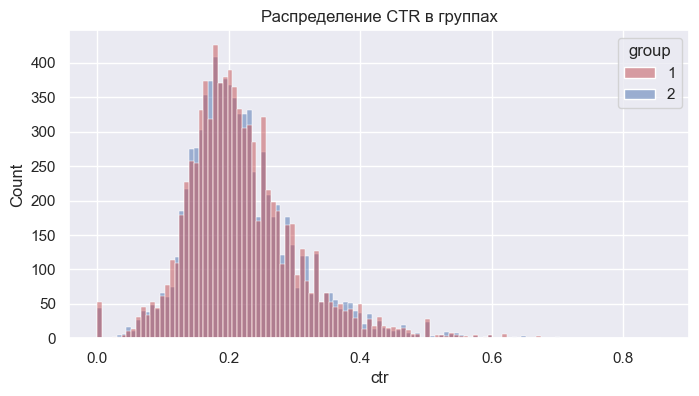

In [7]:
#Посмотрим на распределение CTR у двух групп
sns.set(rc={'figure.figsize':(8,4)})
groups = sns.histplot(data = aa, 
              x='ctr', 
              hue='group', 
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)
title = plt.title('Распределение CTR в группах')

Визуально распределения CTR в группах 1 и 2 накладываются друг на друга, унимодальны и очень похожи на нормальные.

In [8]:
#критерий Левена - проверим гомогенность дисперсий для t-теста
stats.levene(aa[aa.group==1].ctr, aa[aa.group==2].ctr)

LeveneResult(statistic=np.float64(0.03142725417463711), pvalue=np.float64(0.8592926820610571))

Нулевая гипотеза Левена: дисперсии в двух выборках не имеют значимых различий.\
Pvalue> 0.05.\
То есть мы не можем отвергнуть нулевую гипотезу. Гомогенность дисперсий статистически обоснована.

Проведем t-test.

In [9]:
stats.ttest_ind(aa[aa.group==1].ctr,
               aa[aa.group==2].ctr,
                equal_var=True)#дисперсии гомогенны

TtestResult(statistic=np.float64(-0.5694872521653312), pvalue=np.float64(0.5690331104599564), df=np.float64(16851.0))

P-value > 0.05, не можем отвергнуть нулевую гипотезу.\
То есть в CTR групп 1 и 2 нет существенных различий в период, предшествующий A/B-тесту.

Также параллльно проверим разночтения в группах непараметрическим тестом Манна-Уитни на случай ненормальности рапределений CTR в группах.\
Нулевая гипотеза Манна-Уитни: P(X>Y)=P(Y>X).

In [10]:
print(stats.mannwhitneyu(aa[aa.group==1].ctr,
                aa[aa.group==2].ctr))
A_gt_B = 0
for _ in range(10000):
    A_gt_B += aa[aa.group==1].ctr.sample().values[0] > aa[aa.group==2].ctr.sample().values[0]

print(f'В {A_gt_B/100} % случаев A > B. Должно получиться около 50%')

MannwhitneyuResult(statistic=np.float64(35397948.5), pvalue=np.float64(0.7444783443961298))
В 49.92 % случаев A > B. Должно получиться около 50%


P-value > 0.05. Мы не можем отвергнуть нулевую гипотезу.\
То есть в CTR групп 1 и 2 действительно нет существенных различий в период, предшествующий A/B-тесту.

Итак:
- Визуально распределения накладываются одно на другое
- не прокрашивается t-test
- не прокрашивается тест Mанна-Уитни

AA-тест сошелся.

<a id='section4'></a>
### 4. АB-тест

<!-- Пришло время проанализировать результаты эксперимента, который мы провели вместе с командой дата сайентистов.\
Эксперимент проходил с 2024-09-27 по 2024-10-03 включительно.\
Для эксперимента были задействованы 2 и 1 группы. 

В группе 2 был использован один из новых алгоритмов рекомендации постов, группа 1 использовалась в качестве контроля. \
Основная гипотеза заключается в том, что новый алгоритм во 2-й группе приведет к увеличению CTR. \
Ваша задача — проанализировать данные А/B-теста. 

Выбрать метод анализа и сравнить CTR в двух группах (мы разбирали t-тест, Пуассоновский бутстреп, тест Манна-Уитни,\
t-тест на сглаженном ctr (α=5) а также t-тест и тест Манна-Уитни поверх бакетного преобразования).\
Сравните данные этими тестами. А еще посмотрите на распределения глазами. Почему тесты сработали именно так? \
Опишите потенциальную ситуацию, когда такое изменение могло произойти. Тут нет идеального ответа, подумайте.\
Напишите рекомендацию, будем ли мы раскатывать новый алгоритм на всех новых пользователей или все-таки не стоит.\
При выполнении задания важно обосновать и аргументировать ваш вывод. -->

Эксперимент проходил с 2024-09-27 по 2024-10-03 включительно.\
Для эксперимента были задействованы 1 и 2 группы (греппы A и B).

В группе 2 предлагаются посты, похожие на лайкнутые, группа 1 используется в качестве контроля.\
Основная гипотеза заключается в том, что новый алгоритм во 2-й группе приведет к увеличению CTR.

Выберем метод анализа и сравним CTR методами:
- t-тест,
- тест Манна-Уитни
- Пуассоновский бутстреп
- t-тест на сглаженном ctr (α=5)
- t-тест и тест Манна-Уитни поверх бакетного преобразования)
   
А ткже посмотрим на распределения глазами.

In [11]:
q = """
SELECT group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM portfolio.feed_actions_group 
WHERE toDate(time) between '2024-09-27' and '2024-10-03'
    and group in (1,2)
GROUP BY group, user_id
"""

ab = client.query_df(q)
A = ab[ab.group == 1]
B = ab[ab.group == 2]

In [12]:
ab.groupby('group').count()

,user_id,likes,views,ctr
group,,,,
1,10020,10020,10020,10020
2,9877,9877,9877,9877


В группах 1 и 2 по-прежнему примерно одинаковое количество пользователей. Все ок.

### T-test

Плюс T-test в его скорости. Минус - он требователен к виду распределения метрики.

In [13]:
stats.ttest_ind(A.ctr,
                B.ctr,
                equal_var=False)#можно не проверять гомогенность дисперсий

TtestResult(statistic=np.float64(0.405149191311259), pvalue=np.float64(0.6853733311407633), df=np.float64(15811.22649797086))

In [14]:
#а можно провести tt прямо в кликхаусе
q = """
WITH welchTTest(ctr, exp_index) as ttest

select tupleElement(ttest,1) as statistic,
    tupleElement(ttest,2) as p_value
FROM (SELECT group, 
        case when group = 1 then 0 else 1 end as exp_index,
        user_id, 
        sum(action = 'like') as likes,
        sum(action = 'view') as views,
        likes/views as ctr
    FROM portfolio.feed_actions_group
    WHERE toDate(time) between '2024-09-27' and '2024-10-03'
        and group in (1,2)
    GROUP BY group, user_id)
"""

result_tt = client.query_df(q)
result_tt

,statistic,p_value
0,0.405149,0.685373


P-value > 0.05, значит отклонения получены случайно, разницы между выборками по CTR нет.

Text(0.5, 1.0, 'Распределение CTR в контрольной (1) и экспериментальной (2) группах')

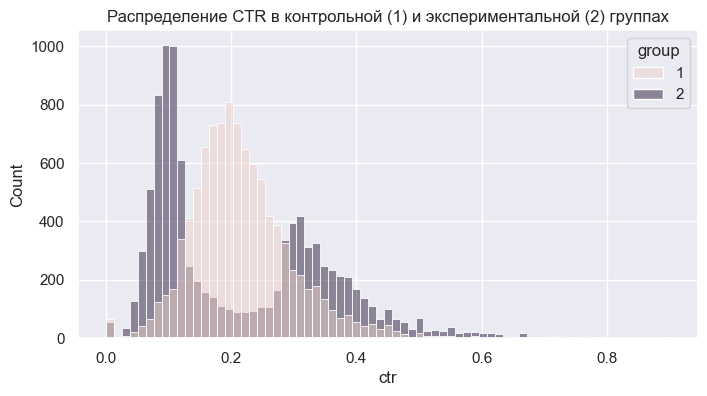

In [15]:
groups = sns.histplot(data = ab, 
              x='ctr', 
              hue='group', 
              alpha=0.5,
              kde=False)
plt.title('Распределение CTR в контрольной (1) и экспериментальной (2) группах')

Но распределение 2 группы совершенно не похоже на нормальное. Поэтому озаботимся проведением теста Манна-Уитни.

### Тест Манна-Уитни

Тест Манна-Уитни не требователен к виду распределения, но более ресурсозатратен, чем T-test.

In [16]:
stats.mannwhitneyu(A.ctr, 
                   B.ctr,
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(55189913.0), pvalue=np.float64(4.632205841806026e-45))

In [17]:
A_gt_B = 0
for _ in range(10000):
    A_gt_B+= ab[ab.group == 1].ctr.sample().values[0] > ab[ab.group == 2].ctr.sample().values[0]
    
print('В', A_gt_B/100, '% случаев A > B. Должно получиться около 50%')

В 56.2 % случаев A > B. Должно получиться около 50%


Манн-Уитни прокрасился.

Посчитаем общегруппой CTR, чтобы понять в какую сторону произошли изменения.

Общегрупповой CTR рассчитаем по формуле:
$$
globalCTR = \frac{sum(likes)} {sum(views)}
$$

In [18]:
#Посчитаем глобальные CTR
global_ctr_1 = A.likes.sum()/A.views.sum()
global_ctr_2 = B.likes.sum()/B.views.sum()
print(f'CTR в контрольной группе {global_ctr_1:.4f}, CTR в экспериментальной группе {global_ctr_2:.4f}')

CTR в контрольной группе 0.2096, CTR в экспериментальной группе 0.2003


CTR в контрольной группе выше, чем в экспериментальной.\
Вывод - есть значимые изменения в CTR в контрольной и экспериментальной группах.\
Но изменения в худшую сторону. Тест Манна-Уитни показывает, что раскатывать изменения не рекомендуется.

### Т-test и Манн-Уитни на сглаженном CTR (α = 5)

Среди пользователей есть те, у которых небольшое количество просмотров.
Оценка их CTR недостаточно точна например, если у пользователя 1 просмотр и 1 лайк, то CTR равен 1).\
Это зашумляет общую оценку метрики.\
В таких условиях эффективно применять сглаженную метрику.\
Можно использовать сглаживание Лапласа.\
Здесь:
- n - номер пользователя
- globalCTR - общегрупповой CTR
- α - гиперпараметр

$$
smoothed CTR = \frac{likes_n + α∗globalCTR}{views_n + α}
$$

In [19]:
def get_smothed_ctr(user_likes, user_views, global_ctr, alpha):
    smothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
    return smothed_ctr

Вспоним значения общегрупповых CTR, посчитанные в разделе с тестом Манна-Уитни.

In [20]:
print(f'CTR в контрольной группе {global_ctr_1:.4f}, CTR в экспериментальной группе {global_ctr_2:.4f}')

CTR в контрольной группе 0.2096, CTR в экспериментальной группе 0.2003


In [21]:
group1 = A.copy()
group2 = B.copy()

In [22]:
group1['smothed_ctr'] = A.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_1, 5), axis=1)
group2['smothed_ctr'] = B.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_2, 5), axis=1)

Text(0.5, 1.0, 'Распределение сглаженного CTR контрольной группы')

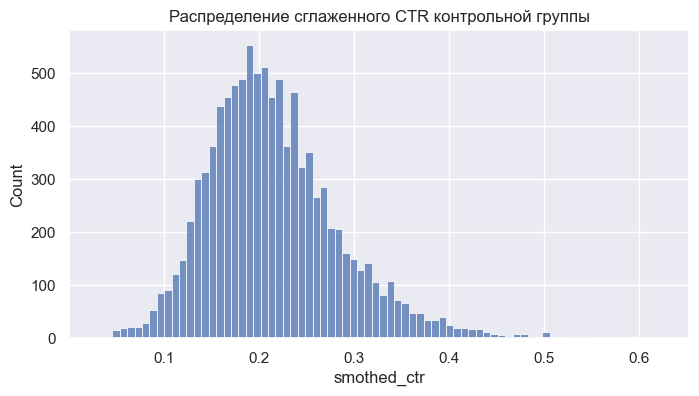

In [23]:
sns.histplot(group1['smothed_ctr'], 
             kde = False)
plt.title('Распределение сглаженного CTR контрольной группы')

Text(0.5, 1.0, 'Распределение сглаженного CTR экспериментальной группы')

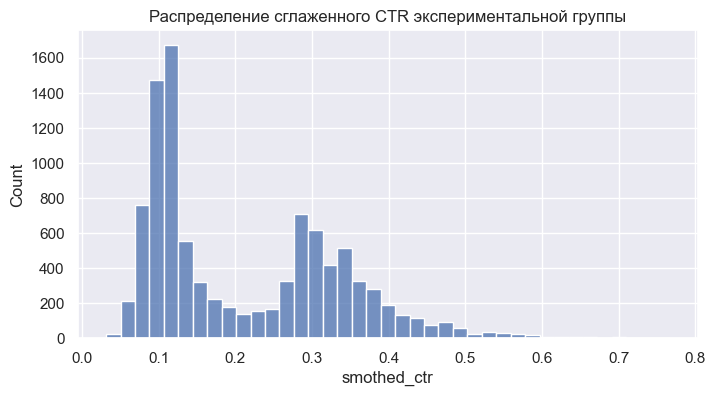

In [24]:
sns.histplot(group2.smothed_ctr, 
             kde = False)
plt.title('Распределение сглаженного CTR экспериментальной группы')

Проведем T-test на сглаженном CTR.

In [25]:
stats.ttest_ind(group1.smothed_ctr,
                group2.smothed_ctr,
                equal_var=False)

TtestResult(statistic=np.float64(1.9460491517027292), pvalue=np.float64(0.051666790153189965), df=np.float64(15580.626569177026))

Т-тест на сглаженном CTR показывает меньшую случайность различий. Это мб связано с тем, что распределение 2 группы стало ближе к нормальному и тест стал показывать более правдободобный результат.

Проведем тест Манна-Уитни на сглаженном CTR.

In [26]:
stats.mannwhitneyu(group1.smothed_ctr,
                   group2.smothed_ctr,
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(55528353.0), pvalue=np.float64(2.3965340393742863e-50))

In [27]:
A_gt_B = 0
for _ in range(10000):
    A_gt_B+= group1.smothed_ctr.sample().values[0] > group2.smothed_ctr.sample().values[0]
    
print('В', A_gt_B/100, '% случаев A > B. Должно получиться около 50%')

В 55.88 % случаев A > B. Должно получиться около 50%


Манн-Уитни показывает примерно тот же результат, как и без сглаживания CTR.

Итого: тесты на сглаженном CTR подтверждают ранее сделанные выводы.

### Пуассоновский бутстреп

Суть бутстрепа.\
Мы предполагаем, что наша выборка репрезентативна.\
Генерируем из нее более мелкие выборки и строим распределение метрики в этих выборках.

Плюс бутстрепа в том, что он не требователен к типу распределений и видам метрик.\
Минус - он ресурсозатратен.

*в непарметрическом бутстрепе выборки делаются с возвращениями

Порядок действий:
1. Генерим выборку из контрольной группы (пользователи, лайки, просмотры)
2. Из распределения Пуассона генерим, сколько раз конкретный пользователь попал в выборку. Получится колонка вес - weights_А.
3. Считаем глобальный CTR для каждой из групп по формуле:

$$
GlobalCTR_A = \frac{sum(likes_A*weights_A)}{sum(views_A*weights_A)}
$$

4. Такую же процедуру проделываем с экспериментальной группой B.
5. Считаем разницу между GlobalCTR_A и GlobalCTR_B.
6. Повторяем эту процедуру много раз (например, 2000).
7. Получаем распределение из 2000 величин разницы между CTR.

In [28]:
def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):

    poisson_bootstraps1 = stats.poisson(1).rvs(
        (n_bootstrap, len(likes1))).astype(np.int64)

    poisson_bootstraps2 = stats.poisson(1).rvs(
            (n_bootstrap, len(likes2))).astype(np.int64)
    
    globalCTR1 = (poisson_bootstraps1*likes1).sum(axis=1)/(poisson_bootstraps1*views1).sum(axis=1)
    
    globalCTR2 = (poisson_bootstraps2*likes2).sum(axis=1)/(poisson_bootstraps2*views2).sum(axis=1)

    return globalCTR1, globalCTR2

Text(0.5, 1.0, 'Распределение общегрупповых CTR контрольной (1) и экспериментальной (2) групп')

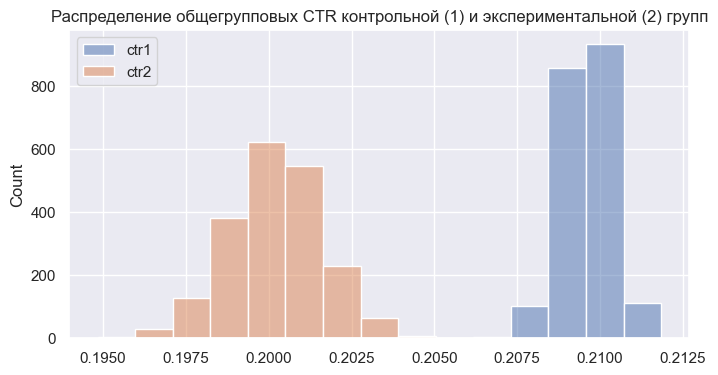

In [29]:
likes1 = A.likes.to_numpy()
views1 = A.views.to_numpy()
likes2 = B.likes.to_numpy()
views2 = B.views.to_numpy()

ctr1, ctr2 = bootstrap(likes1, views1, likes2, views2)
ctr = pd.DataFrame({'ctr1':ctr1, 'ctr2':ctr2})

sns.histplot(ctr)
plt.title('Распределение общегрупповых CTR контрольной (1) и экспериментальной (2) групп')

Распределения не пересекаются, значит p-value = 0, то есть разница между выборками есть.

Text(0.5, 1.0, 'Разница между общегрупповыми CTR')

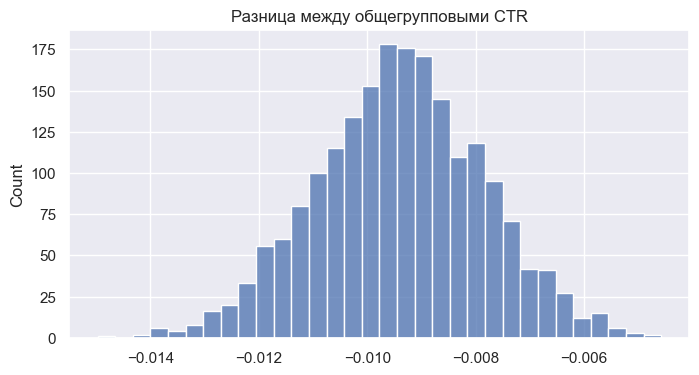

In [30]:
#Разница между глобальными CTR
sns.histplot(ctr2 - ctr1)
plt.title('Разница между общегрупповыми CTR')

Разница между CTR меньше 0 и не равна 0, значит CTR в выборке 1 выше, чем в 2. И это неслучайно.\
То есть наши изменения привели к снижению CTR. Раскатывать нельзя.

Пуассоновский бутстреп подтверждает ранее сделанные выводы.

### T-test и тест Манна-Уитни поверх бакетного преобразования

Суть бакетного преобразования.\
Делим пользователей на N бакетов (корзинок). 1 пользователь попадает ровно в 1 бакет.\
Число бакетов - это гиперпараметр. В индустрии чаще всего 100-200.\
Возьмем 50, так как у нас всего 10000 пользователей в группе, тогда в каждом бакете будет по 200 пользователей.\
Внутри каждого бакета посчитаем среднее значение метрики.\
Поверх бакетов проведем стандартные тесты.

In [31]:
#функция для хеширования
def ab_split(id, salt='exp_salt', n_groups=50):
    test_id = str(id) + '-' + str(salt)
    test_id_digest = hashlib.md5(test_id.encode('ascii')).hexdigest()
    test_id_final_int = int(test_id_digest, 16)
    return test_id_final_int % n_groups

ab['bucket'] = ab.user_id.swifter.apply(ab_split)

Pandas Apply:   0%|          | 0/19897 [00:00<?, ?it/s]

In [32]:
ab_result = ab.groupby(['group','bucket'], as_index=False).agg({'likes': sum, 'views': sum})
ab_result['bucket_ctr'] = ab_result.likes/ab_result.views

In [33]:
stats.mannwhitneyu(ab_result[ab_result.group==1].bucket_ctr, 
                   ab_result[ab_result.group==2].bucket_ctr, 
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(2059.0), pvalue=np.float64(2.494518407100771e-08))

Манн-Уитни показывает отличие.

In [34]:
stats.ttest_ind(ab_result[ab_result.group==1].bucket_ctr, ab_result[ab_result.group==2].bucket_ctr, alternative = 'two-sided')

TtestResult(statistic=np.float64(6.585656756668171), pvalue=np.float64(2.2642171822818295e-09), df=np.float64(98.0))

Т-тест также показывает отличие.

Text(0.5, 1.0, 'Распределение бакетного CTR в контрольной (1) и экспериментальной (2) группах')

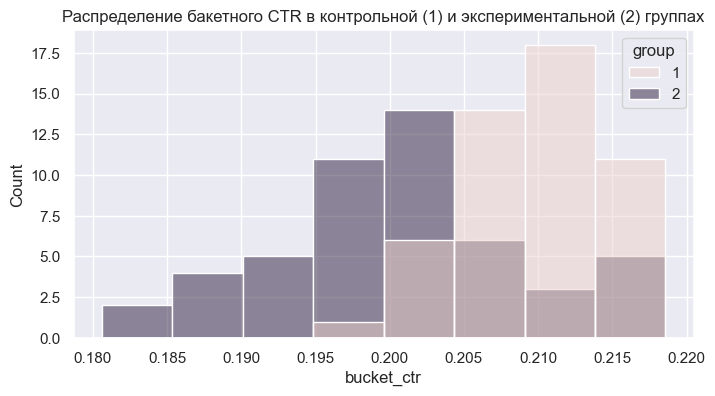

In [35]:
#Нарисуем бакетное распределение
sns.set(rc = {'figure.figsize': (8, 4)})
groups = sns.histplot(data = ab_result, x = 'bucket_ctr', hue = 'group', alpha = 0.5, kde = False)
plt.title('Распределение бакетного CTR в контрольной (1) и экспериментальной (2) группах')

Тесты показали наличие значимых отличий.\
Кроме того, распределение бакетов 2 группы сдвинуто влево: в экспериментальной группе значение CTR ухудшилось.

<a id='section5'></a>
### 5. Общий вывод

Что сделано:
1. проведено сплитование, проверена его корректность.
2. проведен АА-тест.
3. проведены АВ-тесты допустимыми способами.

**Вывод**: тесты показали значимые изменения в CTR в сторону ухудшения метрики.
Новый алгоритм раскатывать **не рекомендуется**.